In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Social_Network_Ads.csv")

In [4]:
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
84,15798659,Female,30,62000,0
81,15668385,Male,39,42000,0
75,15651983,Male,34,112000,1
283,15663249,Female,52,21000,1
25,15631159,Male,47,20000,1


In [5]:
df= df.drop(columns=['User ID','Gender'])

In [6]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [7]:
df.shape

(400, 3)

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((280, 2), (120, 2))

In [33]:
y_train.shape, y_test.shape, X_train.shape, X_test.shape

((280,), (120,), (280, 2), (120, 2))

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
#bcoz scaler give output in numoy array
X_train_scaled = pd.DataFrame(X_train_scaled, columns= X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns= X_test.columns)

In [19]:
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [28]:
np.round(X_train_scaled.describe(),1)


,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


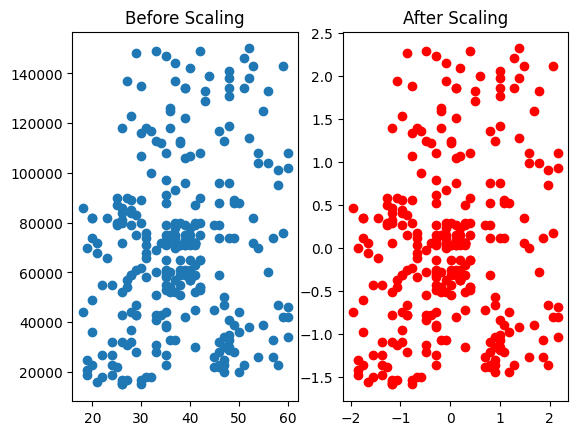

In [31]:
fig, (ax1, ax2) = plt.subplots(ncols=2)

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

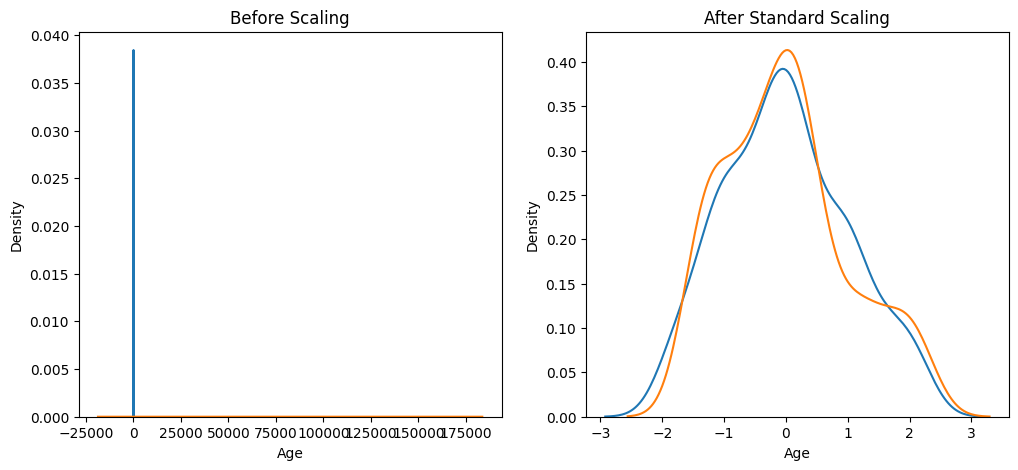

In [34]:
ig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

In [38]:
df = pd.concat([
    df,
    pd.DataFrame({
        'Age':[5,90,95],
        'EstimatedSalary':[1000,250000,350000],
        'Purchased':[0,1,1]
    })
], ignore_index=True)


In [46]:
X_train,X_test,y_train,y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)

In [48]:
X_train.shape,X_test.shape

((282, 2), (121, 2))

In [52]:
scaler.fit(X_train)

x_train_scaled= scaler.transform(X_train)
x_test_scaled= scaler.transform(X_test)

In [56]:
x_train_scaled= pd.DataFrame(x_train_scaled, columns=X_train.columns)
x_test_scaled= pd.DataFrame(x_test_scaled, columns=X_test.columns)

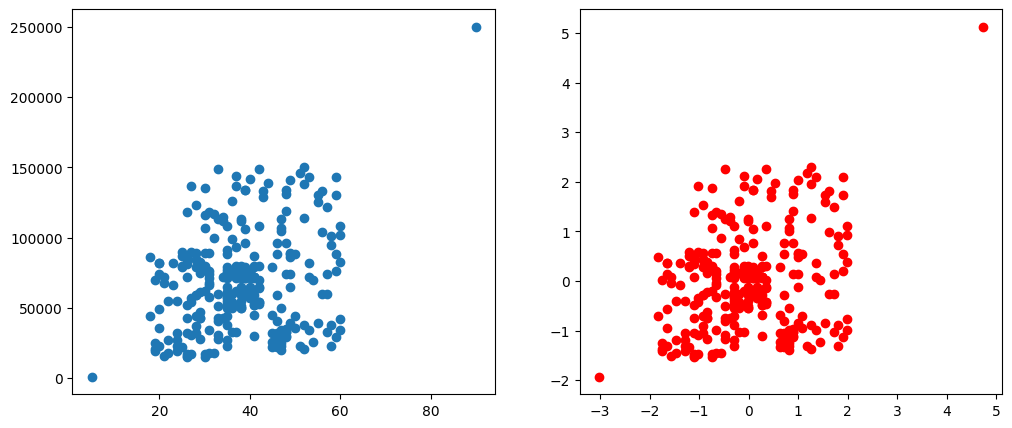

In [65]:
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,5))

ax[0].scatter(X_train['Age'],X_train['EstimatedSalary'])
ax[1].scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'],color='r')